## PREPARING DATA

In [2]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
from matplotlib.ticker import MultipleLocator


In [4]:
pd.set_option("display.max_columns", None)

In [5]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent.parent
    print(script_dir)
    data_folder = script_dir /'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [6]:
userInputDataRaw = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIGraw = loadDataFromFile("Data:Previous experiments-preprocessed")

C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 257 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\UserPrevious experiments-preprocessed.json
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 229277 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\Data:Previous experiments-preprocessed.json


In [7]:
timeSeriesData_BIGraw = timeSeriesData_BIGraw.set_index("seconds",drop=False)

In [8]:
a = userInputDataRaw.index
b = timeSeriesData_BIGraw["keys"].unique()
diff_all = list(set(a).symmetric_difference(set(b)))
print(diff_all)  
userInputDataRaw.index = timeSeriesData_BIGraw["keys"].unique()
print(userInputDataRaw.index)

[6, 49, 257, 258]
Index([  0,   1,   2,   3,   4,   5,   7,   8,   9,  10,
       ...
       249, 250, 251, 252, 253, 254, 255, 256, 257, 258],
      dtype='int64', length=257)


In [9]:
# Convert back to timedelta
timeSeriesData_BIGraw['timestamp'] = pd.to_timedelta(timeSeriesData_BIGraw['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIGraw ["datetime_timestamp"]= timeSeriesData_BIGraw['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)


columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment']
columns_timedelta = ['time taken total','time taken before insertion',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']
# Ensure target columns are of object type before assignment
userInputDataRaw[columns_datetime] = userInputDataRaw[columns_datetime].astype('object')
userInputDataRaw[columns_timedelta] = userInputDataRaw[columns_timedelta].astype('object')

userInputDataRaw.loc[:,columns_datetime] = userInputDataRaw.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputDataRaw.loc[:,columns_timedelta] = userInputDataRaw.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

In [10]:
timeSeriesData_BIG_Original = timeSeriesData_BIGraw.copy()
userInputData_Original = userInputDataRaw.copy()

In [11]:
userInputData_Original

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
0,InsertingSourcePollutant,on,None,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.0,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01 00:00:00,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543,0 days 00:05:00,0 days 00:42:23,2543,300,2843,270,-30,299,4.3501,299.0,8.1928,243,NaN,NaN,Id=2:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,4.10260,4.342653,8.13641,8.191397,NaN,NaN,8.03289,8.186653,1.338333,0.000302,5.003467,0.001410,NaN,NaN,-2.25,3.0,"[-2.25, 3.0]",NaN,NaN,2.4,3.05,1.70,3.05,"[None, None]","[2.4, 3.05]","[1.7000000000000002, 3.05]",NaN,4.65,3.95
1,InsertingSourcePollutant,on,None,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.0,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02 00:00:00,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000,0 days 00:05:20,0 days 00:16:40,1000,320,1320,270,-30,299,1.1333,201.0,0.3304,80,NaN,NaN,Id=1:BME680:breathVocEquivalent MAX value VOC ...,Id=2:BME680:breathVocEquivalent MAX value VOC ...,0.96260,1.130830,0.30518,0.330042,NaN,NaN,0.74384,1.123456,0.050000,-0.000188,0.149700,0.002748,NaN,NaN,-2.25,3.0,"[-

In [12]:
userInputData_Original["room"].unique()

array(['Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55',
       'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1',
       'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90',
       'Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0',
       'Κρεβατοκάμαρα Όλοι οι αισθητήρες μαζί Π:1.80 , Δ:2.00'],
      dtype=object)

In [13]:
#keep the data from the last set experiments made that have the 3 sensors in a triangle shape,they have 16 particular points in the space d
room_mask = userInputData_Original["room"].isin(['Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0'])
mask = room_mask  
userInputData_Original = userInputData_Original.loc[mask]
timeSeriesData_BIG_Original = timeSeriesData_BIG_Original.loc[timeSeriesData_BIG_Original["keys"].isin(userInputData_Original.index)]

In [14]:
userInputData_Original

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
79,NoSourcePollutantInserted,on,on,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,NaN,None,on,2025-10-02 20:42:09,2025-10-02 20:37:01,2025-10-02 20:52:58,2025-10-02 00:00:00,2025-10-02 20:37:03,2025-10-02 20:52:57,0 days 00:15:54,0 days 00:05:07,307,0 days 00:10:47,0 days 00:05:07,307,647,954,270,-30,299,0.4661,262.0,0.2250,299,0.4772,299.0,Id=0:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.45302,0.465942,0.18039,0.223468,0.41637,0.469588,0.41954,0.465622,0.358697,0.000262,0.090906,0.000573,0.251418,0.001445,NaN,NaN,"[None, None]",-1.85,3.5,-0.5,1.7,-2.25,0.4,"[-1.85, 3.5]","[-0.5, 1.7000000000000002]","[-2.25, 0.4]",NaN,NaN,NaN
80,InsertingSourcePollutant,on,on,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,2.0,1.1,None,None,2025-10-02 20:55:56,2025-10-02 20:53:02,2025-10-02 21:05:57,2025-10-02 00:00:00,2025-10-02 20:53:04,2025-10-02 21:05:55,0 days 00:12:51,0 days 00:02:53,173,0 days 00:09:58,0 days 00:02:53,173,598,771,270,-30,299,0.5238,258.0,0.1611,199,1.2086,299.0,Id=0:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.44293,0.522223,0.15562,0.160700,1.16940,1.204478,0.76853,1.189132,0.125200,0.000248,0.0

In [15]:
timeSeriesData_BIG_Original

,keys,sensors,VOC,after_insertion,original_value,datetime_timestamp,timestamp,seconds,seconds passed from insertionSource,VOC original,VOC rolling average,original seconds,VOC-capped,VOC rolling average-capped,VOC gradient,VOC rolling average gradient,VOC rolling average standard scaler whole experiment,VOC rolling average-capped standard scaler whole experiment
seconds,,,,,,,,,,,,,,,,,,
-30,79,Id=2:BME680:breathVocEquivalent,0.026,False,True,2025-10-02 20:41:40,0 days 00:04:37,-30,-30,0.493066,0.0365,277,0.026,0.0365,0.00080,0.00080,-1.317429,-1.317429
-30,79,Id=0:BME680:breathVocEquivalent,0.000,False,False,2025-10-02 20:41:40,0 days 00:04:37,-30,-30,0.160967,0.0012,277,0.000,0.0012,0.00000,0.00000,-1.554070,-1.554070
-30,79,Id=1:BME680:breathVocEquivalent,0.226,False,False,2025-10-02 20:41:40,0 days 00:04:37,-30,-30,0.507368,0.2474,277,0.226,0.2474,0.00200,0.00200,0.096388,0.096388
-29,79,Id=2:BME680:breathVocEquivalent,0.028,False,False,2025-10-02 20:41:41,0 days 00:04:38,-29,-29,0.494639,0.0373,278,0.028,0.0373,0.00085,0.00085,-1.312066,-1.312066
-29,79,Id=0:BME680:breathVocEquivalent,0.000,False,False,2025-10-02 20:41:41,0 days 00:04:38,-29,-29,0.160991,0.0012,278,0.000,0.0012,0.00005,0.00005,-1.554070,-1.554070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,258,Id=1:BME680:breathVocEquivalent,1.421,True,True,2025-10-24 21:59:04,0 days 00:06:46,298,298,2.948842,1.4032,406,1.421,1.4032,-0.00500,-0.00500,0.089182,0.089182
298,258,Id=2:BME680:breathVocEquivalent,3.343,True,False,2025-10-24 21:59:04,0 days 00:06:46,298,298,5.567955,3.3352,406,3.343,3.3352,-0.00835,-0.00835,2.251684,2.251684
299,258,Id=0:BME680:breathVocEquivalent,2.143,True,False,2025-10-24 21:59:05,0 days 00:06:47,299,299,3.110278,2.1139,407,2.143,2.1139,0.01260,0.01260,0.884674,0.884674


In [16]:
column_to_transform = "x-y axis"
userInputData_Original.loc[:,column_to_transform] = userInputData_Original.loc[:,column_to_transform].apply(tuple)

In [17]:
sensors_position_columns = ["position of Id="+str(id) + ":BME680:breathVocEquivalent x-y axis"
                            for id in range(3)]
sensors_euclidian_distance_columns = ["Euclidian distance to Id="+str(id) + ":BME680:breathVocEquivalent"
                                    for id in range(3)]

userInputData_Original.loc[:,sensors_position_columns] = userInputData_Original.loc[:,sensors_position_columns].applymap(lambda lst: [round(x,2) for x in lst])
userInputData_Original.loc[:,sensors_euclidian_distance_columns] = userInputData_Original.loc[:,sensors_euclidian_distance_columns].round(2)


In [18]:
sensors_position_columns = ["position of Id="+str(id) + ":BME680:breathVocEquivalent x-y axis"
                            for id in range(3)]
column_to_transform = sensors_position_columns
userInputData_Original.loc[:,column_to_transform] = userInputData_Original.loc[:,column_to_transform].apply(tuple)

In [19]:
userInputData_Original

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
79,NoSourcePollutantInserted,on,on,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,NaN,None,on,2025-10-02 20:42:09,2025-10-02 20:37:01,2025-10-02 20:52:58,2025-10-02 00:00:00,2025-10-02 20:37:03,2025-10-02 20:52:57,0 days 00:15:54,0 days 00:05:07,307,0 days 00:10:47,0 days 00:05:07,307,647,954,270,-30,299,0.4661,262.0,0.2250,299,0.4772,299.0,Id=0:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.45302,0.465942,0.18039,0.223468,0.41637,0.469588,0.41954,0.465622,0.358697,0.000262,0.090906,0.000573,0.251418,0.001445,NaN,NaN,"(None, None)",-1.85,3.5,-0.5,1.7,-2.25,0.4,"[-1.85, 3.5]","[-0.5, 1.7]","[-2.25, 0.4]",NaN,NaN,NaN
80,InsertingSourcePollutant,on,on,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,2.0,1.1,None,None,2025-10-02 20:55:56,2025-10-02 20:53:02,2025-10-02 21:05:57,2025-10-02 00:00:00,2025-10-02 20:53:04,2025-10-02 21:05:55,0 days 00:12:51,0 days 00:02:53,173,0 days 00:09:58,0 days 00:02:53,173,598,771,270,-30,299,0.5238,258.0,0.1611,199,1.2086,299.0,Id=0:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.44293,0.522223,0.15562,0.160700,1.16940,1.204478,0.76853,1.189132,0.125200,0.000248,0.098400,-0.001167

In [20]:
userInputData_Original.columns

Index(['experimentState', 'are-doors-opened', 'are-people-inside',
       'are-windows-opened', 'front-wall', 'item-used', 'notes', 'room',
       'side-right-wall', 'back-wall', 'side-left-wall', 'are-fans-on',
       'no-source-located', 'timestamp InsertingSource',
       'timestamp StartingExperiment', 'timestamp EndingExperiment',
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment', 'time taken total',
       'timestamp InsertingSource timedelta',
       'timestamp InsertingSource seconds', 'time taken after insertion',
       'time taken before insertion', 'time taken before insertion (seconds)',
       'time taken after insertion (seconds)', 'time taken total (seconds)',
       'time taken total (seconds)-capped',
       'time taken before insertion (seconds)-capped',
       'time taken after insertion (seconds)-capped',
       'Id=1:BME680:breathVocEquivalent MAX value VOC rolling average',
       'Id=1:BME680:breathVoc

In [21]:

euclidian_distance_columns = ["Euclidian distance to Id="+str(id)+":BME680:breathVocEquivalent"
                               for id in range(3) ]

mask = userInputData_Original["are-doors-opened"] == "on"
for i in range(3):
    print(f"userInputData_Original[are-doors-opened] == on at id={i}:{np.sort(userInputData_Original.loc[mask,euclidian_distance_columns[i]].unique())}")
mask = userInputData_Original["are-doors-opened"] != "on"    
for i in range(3):
    print(f"userInputData_Original[are-doors-opened] != on at id={i}:{np.sort(userInputData_Original.loc[mask,euclidian_distance_columns[i]].unique())}")

userInputData_Original[are-doors-opened] == on at id=0:[0.35 0.65 1.06 1.1  1.19 1.35 1.49 1.53 1.58 1.68 2.   2.03 2.06 2.1
 2.28 2.41 2.5  2.55 3.02 3.07 3.2  3.29  nan]
userInputData_Original[are-doors-opened] == on at id=1:[0.2  0.8  0.87 0.9  1.02 1.1  1.2  1.28 1.36 1.52 1.56 1.68 1.8  2.01
 2.06 2.15 2.33 2.46 2.58 2.69 2.73 3.04  nan]
userInputData_Original[are-doors-opened] == on at id=2:[0.27 0.71 0.72 0.76 1.08 1.13 1.17 1.3  1.33 1.42 1.6  1.75 1.84 2.07
 2.11 2.21 2.23 2.73 3.11 3.18 3.19 3.56  nan]
userInputData_Original[are-doors-opened] != on at id=0:[0.35 0.65 1.06 1.1  1.19 1.35 1.49 1.68 2.03 2.1  2.28 2.41 3.02 3.07
 3.2  3.29  nan]
userInputData_Original[are-doors-opened] != on at id=1:[0.2  0.8  1.02 1.2  1.28 1.56 1.8  2.01 2.06 2.15 2.33 2.46 2.58 2.69
 2.73 3.04  nan]
userInputData_Original[are-doors-opened] != on at id=2:[0.27 0.71 0.76 1.13 1.3  1.33 1.75 2.07 2.11 2.21 2.23 2.73 3.11 3.18
 3.19 3.56  nan]


In [22]:
userInputData_Original

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,time taken before insertion,time taken before insertion (seconds),time taken after insertion (seconds),time taken total (seconds),time taken total (seconds)-capped,time taken before insertion (seconds)-capped,time taken after insertion (seconds)-capped,Id=1:BME680:breathVocEquivalent MAX value VOC rolling average,Id=1:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent MAX value VOC rolling average,Id=2:BME680:breathVocEquivalent index of MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent MAX value VOC rolling average,Id=0:BME680:breathVocEquivalent index of MAX value VOC rolling average,sensor with MAX value experiment,sensor with second MAX value experiment,Id=1:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=1:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=2:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 90.0% VOC rolling average,Id=0:BME680:breathVocEquivalent quantile 99.0% VOC rolling average,whole experiment quantile 90.0% VOC rolling average,whole experiment quantile 99.0% VOC rolling average,Id=1:BME680:breathVocEquivalent VOC mean calm period,Id=1:BME680:breathVocEquivalent VOC gradient mean calm period,Id=2:BME680:breathVocEquivalent VOC mean calm period,Id=2:BME680:breathVocEquivalent VOC gradient mean calm period,Id=0:BME680:breathVocEquivalent VOC mean calm period,Id=0:BME680:breathVocEquivalent VOC gradient mean calm period,x axis,y axis,x-y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis,position of Id=0:BME680:breathVocEquivalent x-y axis,position of Id=1:BME680:breathVocEquivalent x-y axis,position of Id=2:BME680:breathVocEquivalent x-y axis,Euclidian distance to Id=0:BME680:breathVocEquivalent,Euclidian distance to Id=1:BME680:breathVocEquivalent,Euclidian distance to Id=2:BME680:breathVocEquivalent
79,NoSourcePollutantInserted,on,on,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,NaN,NaN,None,on,2025-10-02 20:42:09,2025-10-02 20:37:01,2025-10-02 20:52:58,2025-10-02 00:00:00,2025-10-02 20:37:03,2025-10-02 20:52:57,0 days 00:15:54,0 days 00:05:07,307,0 days 00:10:47,0 days 00:05:07,307,647,954,270,-30,299,0.4661,262.0,0.2250,299,0.4772,299.0,Id=0:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.45302,0.465942,0.18039,0.223468,0.41637,0.469588,0.41954,0.465622,0.358697,0.000262,0.090906,0.000573,0.251418,0.001445,NaN,NaN,"(None, None)",-1.85,3.5,-0.5,1.7,-2.25,0.4,"[-1.85, 3.5]","[-0.5, 1.7]","[-2.25, 0.4]",NaN,NaN,NaN
80,InsertingSourcePollutant,on,on,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0...",NaN,2.0,1.1,None,None,2025-10-02 20:55:56,2025-10-02 20:53:02,2025-10-02 21:05:57,2025-10-02 00:00:00,2025-10-02 20:53:04,2025-10-02 21:05:55,0 days 00:12:51,0 days 00:02:53,173,0 days 00:09:58,0 days 00:02:53,173,598,771,270,-30,299,0.5238,258.0,0.1611,199,1.2086,299.0,Id=0:BME680:breathVocEquivalent MAX value VOC ...,Id=1:BME680:breathVocEquivalent MAX value VOC ...,0.44293,0.522223,0.15562,0.160700,1.16940,1.204478,0.76853,1.189132,0.125200,0.000248,0.098400,-0.001167

In [23]:
timeSeriesData_BIG_Original

,keys,sensors,VOC,after_insertion,original_value,datetime_timestamp,timestamp,seconds,seconds passed from insertionSource,VOC original,VOC rolling average,original seconds,VOC-capped,VOC rolling average-capped,VOC gradient,VOC rolling average gradient,VOC rolling average standard scaler whole experiment,VOC rolling average-capped standard scaler whole experiment
seconds,,,,,,,,,,,,,,,,,,
-30,79,Id=2:BME680:breathVocEquivalent,0.026,False,True,2025-10-02 20:41:40,0 days 00:04:37,-30,-30,0.493066,0.0365,277,0.026,0.0365,0.00080,0.00080,-1.317429,-1.317429
-30,79,Id=0:BME680:breathVocEquivalent,0.000,False,False,2025-10-02 20:41:40,0 days 00:04:37,-30,-30,0.160967,0.0012,277,0.000,0.0012,0.00000,0.00000,-1.554070,-1.554070
-30,79,Id=1:BME680:breathVocEquivalent,0.226,False,False,2025-10-02 20:41:40,0 days 00:04:37,-30,-30,0.507368,0.2474,277,0.226,0.2474,0.00200,0.00200,0.096388,0.096388
-29,79,Id=2:BME680:breathVocEquivalent,0.028,False,False,2025-10-02 20:41:41,0 days 00:04:38,-29,-29,0.494639,0.0373,278,0.028,0.0373,0.00085,0.00085,-1.312066,-1.312066
-29,79,Id=0:BME680:breathVocEquivalent,0.000,False,False,2025-10-02 20:41:41,0 days 00:04:38,-29,-29,0.160991,0.0012,278,0.000,0.0012,0.00005,0.00005,-1.554070,-1.554070
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,258,Id=1:BME680:breathVocEquivalent,1.421,True,True,2025-10-24 21:59:04,0 days 00:06:46,298,298,2.948842,1.4032,406,1.421,1.4032,-0.00500,-0.00500,0.089182,0.089182
298,258,Id=2:BME680:breathVocEquivalent,3.343,True,False,2025-10-24 21:59:04,0 days 00:06:46,298,298,5.567955,3.3352,406,3.343,3.3352,-0.00835,-0.00835,2.251684,2.251684
299,258,Id=0:BME680:breathVocEquivalent,2.143,True,False,2025-10-24 21:59:05,0 days 00:06:47,299,299,3.110278,2.1139,407,2.143,2.1139,0.01260,0.01260,0.884674,0.884674


In [24]:
userInputData_Original.loc[userInputData_Original["are-doors-opened"]=="on"].shape

(66, 67)

In [25]:
userInputData_Original.loc[userInputData_Original["are-doors-opened"]!="on"].shape

(102, 67)

In [26]:
max_before= -30
max_after = 299

column_to_check = "time taken before insertion (seconds)-capped"
mask = userInputData_Original[column_to_check] >max_before
print(f"{column_to_check} < {max_before}:\n {userInputData_Original.loc[mask,column_to_check]}")

column_to_check = "time taken after insertion (seconds)-capped"
mask = userInputData_Original[column_to_check] < max_after
print(f"{column_to_check} < {max_after}:\n {userInputData_Original.loc[mask,column_to_check]}")
print(f"userInputData_Original rows {userInputData_Original.shape[0]}")

time taken before insertion (seconds)-capped < -30:
 86     -8
89    -25
104   -10
122   -16
128    -8
131   -12
139    -8
145   -12
187    -5
221   -11
242    -5
Name: time taken before insertion (seconds)-capped, dtype: int64
time taken after insertion (seconds)-capped < 299:
 Series([], Name: time taken after insertion (seconds)-capped, dtype: int64)
userInputData_Original rows 168


In [27]:
userInputData_Original.columns

Index(['experimentState', 'are-doors-opened', 'are-people-inside',
       'are-windows-opened', 'front-wall', 'item-used', 'notes', 'room',
       'side-right-wall', 'back-wall', 'side-left-wall', 'are-fans-on',
       'no-source-located', 'timestamp InsertingSource',
       'timestamp StartingExperiment', 'timestamp EndingExperiment',
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment', 'time taken total',
       'timestamp InsertingSource timedelta',
       'timestamp InsertingSource seconds', 'time taken after insertion',
       'time taken before insertion', 'time taken before insertion (seconds)',
       'time taken after insertion (seconds)', 'time taken total (seconds)',
       'time taken total (seconds)-capped',
       'time taken before insertion (seconds)-capped',
       'time taken after insertion (seconds)-capped',
       'Id=1:BME680:breathVocEquivalent MAX value VOC rolling average',
       'Id=1:BME680:breathVoc

# LIBRARIES AND FUNCTIONS DECLARACTIONS

## LIBRARIES

In [62]:
# Required imports
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.base import BaseEstimator, TransformerMixin

import math
from itertools import combinations
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import StackingClassifier

In [29]:
# Required imports
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## MODELS

In [63]:

# 1. Logistic Regression
logreg = LogisticRegression(max_iter=5000)
logreg_params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],          # 'l1' requires solver='liblinear' or 'saga'
    "solver": ["lbfgs", "saga"]
}

# 2. Support Vector Classifier
svc = SVC()
svc_params = {
    "kernel": ["rbf"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"]
}

# 3. K-Nearest Neighbors
knn = KNeighborsClassifier()
knn_params = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# 4. Decision Tree Classifier
dt = DecisionTreeClassifier()
dt_params = {
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 5. Random Forest Classifier
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 6. Gradient Boosting Classifier
gbc = GradientBoostingClassifier()
gbc_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# 7. Neural Network (MLPClassifier)
mlp = MLPClassifier(max_iter=3000)
mlp_params = {
    "hidden_layer_sizes": [(50,), (100,), (100, 50)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}


# Combine them into your expected dictionary:
models = {
    "LogisticRegression": (logreg, logreg_params),
    "SVC": (svc, svc_params),
    "KNN": (knn, knn_params),
  #  "DecisionTree": (dt, dt_params),
  #  "RandomForest": (rf, rf_params),
 #   "GradientBoosting": (gbc, gbc_params),
  #  "MLPClassifier": (mlp, mlp_params),
}



## FUNCTIONS

#### get_16_train_positions

In [31]:
def get_16_train_positions(userInputData_Original:pd.DataFrame):
    column_to_check = "x-y axis"
    mask = (userInputData_Original["are-doors-opened"] != "on") & (userInputData_Original["room"] =='Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0' ) & (userInputData_Original[column_to_check] != (None,None))
    training_positions = userInputData_Original.loc[mask,column_to_check].unique()
    return training_positions


#### get_Data_To_Be_Used

In [32]:
def get_Data_To_Be_Used(userInputData_Original:pd.DataFrame,timeSeriesData_BIG_Original:pd.DataFrame,
                        keepOpenDoorData =False,drop_other_positions =True ,closeDoorTraining_openDoorTest = False ,anyOtherMaskToBeUsed = None)->(pd.DataFrame,pd.DataFrame):

    userInputData = userInputData_Original.copy()
    timeSeriesData_BIG = timeSeriesData_BIG_Original.copy()

    # clear the data that doesn't fit to the 330 columns we want
    max_before= -30
    max_after = 299
    
    mask_before = (userInputData["time taken before insertion (seconds)-capped"] == max_before)
    max_after = (userInputData["time taken after insertion (seconds)-capped"] == max_after)
    mask = mask_before & max_after
    print(f"data which doesn't fit our criteria of size:{userInputData.loc[~mask,:].index}")
    userInputData = userInputData.loc[mask,:].copy()
    timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]
    if keepOpenDoorData:
        mask = (userInputData["are-doors-opened"] == "on") | (userInputData["are-doors-opened"] != "on")

    else:
        mask =  userInputData["are-doors-opened"] != "on"

    if anyOtherMaskToBeUsed is not None:
        mask = mask & anyOtherMaskToBeUsed
    userInputData = userInputData.loc[mask].copy()
    #grab all the data that are contained in those experiments
    timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)].copy()
        
    
    if drop_other_positions & (not closeDoorTraining_openDoorTest):
        #from the experiments with door open, drop the positions which doesn't fit to the 16 source position we are going to check the model
        #also drop the experiments with the None values
        axis_list = get_16_train_positions(userInputData_Original)
        axis_mask = userInputData["x-y axis"].isin(axis_list)
        
        mask = axis_mask 
        userInputData = userInputData.loc[mask]
        #grab all the data that are contained in those experiments
        timeSeriesData_BIG = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]

    return userInputData,timeSeriesData_BIG
        

#### build_X_keys_And_Y_target_Arrays

In [33]:
def build_X_keys_And_Y_target_Arrays(userInputData,closeDoorTraining_openDoorTest = False)->(np.array,np.array):
  
    if closeDoorTraining_openDoorTest :
         pass

    else:
        keys = np.array(userInputData.index)
        keys_numpy = keys.reshape(-1,1)
   

        # columns_to_pass = ["Euclidian distance to Id="+str(id)+":BME680:breathVocEquivalent"
        #                            for id in range(3) ]
        # column_size = len(columns_to_pass)
        # target_variables = userInputData.loc[keys,columns_to_pass].to_numpy()
        # target_variables_euclidian_distance_numpy = target_variables.reshape(-1,column_size)
     
    
    
        columns_to_pass = ["x-y axis"]
        flattened = userInputData.loc[keys,columns_to_pass].to_numpy().ravel()
        Label_Encoder = LabelEncoder()
                # Step 1: flatten the array from shape (98, 1) of tuples to (98,) of tuples
        
        # Step 2: convert each tuple to a string "x_y"
        string_labels = np.array([f"{x}_{y}" for (x, y) in flattened])
        
        # Step 3: reshape to (98, 1)
        #string_labels = string_labels.reshape(-1, 1)
        target_variables_positions_numpy =  Label_Encoder.fit_transform(string_labels) 
        
        
        X_train_keys,X_test_keys,Y_train,Y_test = train_test_split(
            keys_numpy,target_variables_positions_numpy,
            test_size=0.16,
            stratify=target_variables_positions_numpy,
            random_state=42
        )
    
    return X_train_keys,X_test_keys,Y_train,Y_test,Label_Encoder

In [34]:
def build_X_from_dataframe(keys_array, df, column_to_take):
    # flatten [[159],[196]...] → [159,196,...]
    keys = keys_array.ravel()

    # number of keys
    N = len(keys)

    # number of time steps per experiment (should be constant)
    example_key = keys[0]
    time_values = df[df["keys"] == example_key]
    T = len(time_values)

    # allocate X
    X = np.zeros((N, T))

    # fill X
    for i, key in enumerate(keys):
        rows = df[df["keys"] == key]
        X[i, :] = rows[column_to_take].values

    return X

In [35]:
def get_Data_Per_Sensor(userInputData,timeSeriesData_BIG) ->pd.DataFrame:
    df_filtered = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData.index)]
    sensors_names = np.sort(timeSeriesData_BIG["sensors"].unique())
    dfs_by_sensor = {
        sensor: df_filtered.loc[df_filtered["sensors"]==sensor]
        for sensor in sensors_names
    }
    return dfs_by_sensor


In [36]:
def build_X_train_And_X_test(userInputData,timeSeriesData_BIG,X_train_keys,X_test_keys,column_to_take ="VOC rolling average")->(np.array,np.array):
    dfs_by_sensor = get_Data_Per_Sensor(userInputData,timeSeriesData_BIG)
    X_train = np.empty((len(dfs_by_sensor),X_train_keys.shape[0],330))
    
    for i, data_per_sensor in enumerate(dfs_by_sensor.values()):
        X_train[i,:,:]= build_X_from_dataframe(X_train_keys,data_per_sensor,column_to_take)
    
    X_test = np.empty((len(dfs_by_sensor),X_test_keys.shape[0],330))
        
    for i, data_per_sensor in enumerate(dfs_by_sensor.values()):
        X_test[i,:,:]= build_X_from_dataframe(X_test_keys,data_per_sensor,column_to_take)

    return X_train,X_test

#### create_The_Arrays_For_The_Models

In [37]:

def create_The_Arrays_For_The_Models(userInputData_Original,timeSeriesData_BIG_Original,apply_functions_to_X_data = [],
                                     column_to_take ="VOC rolling average",keepOpenDoorData =False,drop_other_positions =True ,closeDoorTraining_openDoorTest = False ,anyOtherMaskToBeUsed = None):
    userInputData,timeSeriesData_BIG = get_Data_To_Be_Used(userInputData_Original,timeSeriesData_BIG_Original,
                                                           keepOpenDoorData,drop_other_positions,closeDoorTraining_openDoorTest,anyOtherMaskToBeUsed)
    X_train_keys,X_test_keys,Y_train,Y_test,Label_Encoder = build_X_keys_And_Y_target_Arrays(userInputData)    
    X_train,X_test = build_X_train_And_X_test(userInputData,timeSeriesData_BIG,X_train_keys,X_test_keys,column_to_take)
    if apply_functions_to_X_data is not None and apply_functions_to_X_data is not np.nan:
       for modify_function in apply_functions_to_X_data:
           if modify_function is not None and modify_function is not np.nan:
               X_train,X_test =  modify_function(X_train,X_test)
    return X_train,X_test,Y_train,Y_test,Label_Encoder ,userInputData,timeSeriesData_BIG

In [38]:

    
def findPCAcomponentsCovered(X_train):     
    
    for X_train_per_sensor in X_train:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_train_per_sensor)
        # Step 2: Apply PCA
        pca = PCA()
        X_pca = pca.fit_transform(X_scaled)
        
        # Step 3: Explained variance
        explained_variance = pca.explained_variance_ratio_
        cumulative_variance = np.cumsum(explained_variance)
        
        # Only display first 10 components max
        max_components = min(10, len(explained_variance))
        ev_to_plot = explained_variance[:max_components]
        cum_to_plot = cumulative_variance[:max_components]
        
        # Step 4: Bar plot of cumulative explained variance
        plt.figure(figsize=(8,5))
        plt.bar(range(1, max_components + 1), cum_to_plot)
        plt.xlabel('Number of PCA components')
        plt.ylabel('Cumulative explained variance')
        plt.title('Cumulative explained variance (first 10 components)')
        plt.grid(True, axis='y')
        plt.show()
        
        # Step 5: Optimal number of components for ~90% variance
        optimal_components = np.argmax(cumulative_variance >= 0.90) + 1
        print("Optimal number of components to explain ~90% variance:", optimal_components)


In [39]:
def printPCA2components(X_train,Y_train):
    for i in range(X_train.shape[0]):
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_train[i])
        
        # --- Step 2: Reduce to 2 components ---
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        # --- Step 3: Scatter plot with hue based on Y_train ---
        plt.figure(figsize=(8,6))
        
        # Using seaborn for easy color scaling
        sns.scatterplot(
            x=X_pca[:,0], 
            y=X_pca[:,1], 
            hue=Y_train_Euclidians[:,i],              # color represents Y_train
             palette="coolwarm",         # continuous color palette
            s=80,                      # marker size
            alpha=0.8
        )
        
        plt.xlabel("PCA Component 1")
        plt.ylabel("PCA Component 2")
        plt.title("2D PCA of X_train colored by Y_train")
        plt.legend(title="Y_train", bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        plt.show()

In [40]:
class ColumnSliceTransformer(BaseEstimator, TransformerMixin):
    """
    Transformer that slices input columns into n_slices parts and returns the slice indexed by slice_idx.
    
    Parameters
    ----------
    n_slices : int
        Total number of slices to split the columns into.
    slice_idx : int
        Index of the slice to select (0-based).
    """
    def __init__(self, n_slices=3, slice_idx=0):
        self.n_slices = n_slices
        self.slice_idx = slice_idx
        
    def fit(self, X, y=None):
        # Number of columns in the input
        self.n_cols_ = X.shape[1]
        # Compute size of each slice
        self.slice_size_ = int(np.ceil(self.n_cols_ / self.n_slices))
        return self

    def transform(self, X):
        # Compute start and end indices for this slice
        start = self.slice_idx * self.slice_size_
        end = min((self.slice_idx + 1) * self.slice_size_, self.n_cols_)
        return X[:, start:end]

#### run_grid_search_per_model

In [41]:

def run_grid_search_per_model(X_train, y_train,cv_number,verbose,name,model,params,sensors_numbers,sensor_data_to_grab):
        PCA__n_components = [2,3,4,5,6,8,10]

        estimators_with_no_scaling_need = ['RandomForest','DecisionTree','GradientBoosting']
        print(f"sensors_numbers:{sensors_numbers}")
        print(f"sensor_data_to_grab:{sensor_data_to_grab}")
        results = {}
    
        if name in estimators_with_no_scaling_need:
             pipe = Pipeline([
                 ('columnslice',ColumnSliceTransformer( n_slices=sensors_numbers, slice_idx=sensor_data_to_grab)),
                 ('model', model)
             ]) 
        else:
             pipe = Pipeline([
                 ('columnslice',ColumnSliceTransformer( n_slices=sensors_numbers, slice_idx=sensor_data_to_grab)),
                 ('scaler', StandardScaler()),
                 ('PCA', PCA()),
                 ('model', model)
             ])
        # Build a correct param grid:
        param_grid = {
            **{'model__' + k: v for k, v in params.items()}
        }
        if name not in estimators_with_no_scaling_need:
            param_grid['PCA__n_components'] = PCA__n_components
            
        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=cv_number,
            n_jobs=-1,
            scoring='accuracy',
            verbose=2
        )
     
        grid.fit(X_train, y_train)
    
        results["name"]  = name
        results["model"] = grid.best_estimator_
        results["parameters"] = grid.best_params_
        results["score"] = grid.best_score_
    
        return results

def run_grid_search_find_optimal_model_per_sensor(X_train, y_train,cv_number,verbose,models,sensors_numbers=3,sensor_data_to_grab=0):
    #put a score way worse than abest_score_nything we should have
    best_result = {
        "score" : -9999,
        "model" : '',
        "parameters" : {}    
    }
    for name, (model, params) in models.items():
        print(f"Running GridSearchCV for {name}...")

        results = run_grid_search_per_model(X_train, y_train,cv_number,verbose,name,model,params,sensors_numbers,sensor_data_to_grab)
        print(results)

        if (results["score"] >  best_result["score"]) :
            best_result["name"] = results["name"]
     #       print(best_result["name"])
            best_result["score"] = results["score"]
     #       print(best_result["score"])
            best_result["model"] = results["model"]
       #     print(best_result["model"])
            best_result["parameters"] = results["parameters"]
       #     print(best_result["parameters"])
    return best_result


def run_grid_search_find_optimal_model_per_sensor_for_all_sensors(X_train, y_train,cv_number,verbose,models,sensors_numbers):

    best_results_for_all_sensors = {}
    
    for sensor_data_to_grab in range(sensors_numbers):
        print(f"for sensor with id:{sensor_data_to_grab}")
        best_results_for_all_sensors[sensor_data_to_grab]  =run_grid_search_find_optimal_model_per_sensor(X_train, y_train,cv_number,verbose,models,sensors_numbers,sensor_data_to_grab)

    return best_results_for_all_sensors

#### find_best_stacked_regression_Pre_Given

In [64]:
def find_best_stacked_regression_Pre_Given(X_train, y_train,cv_number,verbose,models,best_result_per_sensor):
    
    best_result = {
        "score" : -10,
        "model" : '',
        "parameters" : {} 
    }
    print("For Stacking Classifier")
    for final_estimator_name, (final_estimator_model, final_estimator_params) in models.items():
            
        base_estimators = [(str(sensor_names),base_best_result['model']) 
                               for sensor_names,base_best_result in best_result_per_sensor.items()]
    
       # print(f"base_estimators{base_estimators}")
        stacked_Estimator = StackingClassifier(
            estimators=base_estimators,
            final_estimator=final_estimator_model,  # we will tune this
            passthrough=True           # include original features if you want
        )
        param_grid = {
            **{'final_estimator' +'__' + k: v for k, v in final_estimator_params.items()}
        }
  
        stacked_grid = GridSearchCV(stacked_Estimator,param_grid,cv=cv_number,verbose=verbose,n_jobs=-1,scoring='accuracy')
        stacked_grid.fit(X_train, y_train)
    
        
        if stacked_grid.best_score_ > best_result["score"]:
                best_result["name"]  = final_estimator_name
                best_result["model"] = stacked_grid.best_estimator_
                best_result["parameters"] = stacked_grid.best_params_
                best_result["score"] = stacked_grid.best_score_ 
    return  best_result           

#### getPredictedValues

In [43]:
#PREDICT AND SEE INDIVIDUAL RESULTS
def getPredictedValues(X_test,Y_test,best_results_for_all_sensors,sensors_numbers,is_Stacked = False):


   if (is_Stacked is False): 
       predict_Y = np.empty((Y_test.shape[0],sensors_numbers))
        
       for i in range(sensors_numbers):
            print(f"For sensor with id={i}")
            print(best_results_for_all_sensors)
            predict_Y[:,i] = best_results_for_all_sensors[i]["model"].predict(X_test)
   else:
        predict_Y = np.empty((Y_test.shape[0]))

        predict_Y = best_results_for_all_sensors["model"].predict(X_test)

   return predict_Y
       

#### STACK_X_TRAIN_X_TEST

In [44]:
# MAKE THE X_TRAIN AND X_TEST 3 DIMENSION STACKED INTO THE COLUMNS


def stack_X_train_And_X_Test(X_train,X_test):
    sensors_numbers = X_train.shape[0]
    X_train_Stacked = np.column_stack(tuple(X_train))
    X_test_Stacked  = np.column_stack(tuple(X_test))
    return X_train_Stacked,X_test_Stacked,sensors_numbers

#### trainModels_PrintResults_AndGetPredictedValues

In [45]:
def trainModels_PrintResults_AndGetPredictedValues(userInputData, X_train,X_test,Y_train,Y_test,Label_Encoder,models):
    cv_number = 5
    verbose = 0
    X_train,X_test,sensors_numbers = stack_X_train_And_X_Test(X_train,X_test)
    print(f"sensors_numbers:{sensors_numbers}")

    best_results_for_all_sensors = {}

    best_results_for_all_sensors = run_grid_search_find_optimal_model_per_sensor_for_all_sensors(X_train, Y_train,cv_number,verbose,models,sensors_numbers)
    print(type(best_results_for_all_sensors[i]["model"]))
    print(best_results_for_all_sensors[i]["model"])
    
    Y_predict_Base = getPredictedValues(X_test,Y_test,best_results_for_all_sensors,sensors_numbers,is_Stacked = False)
    
    for Y_predict in np.transpose(Y_predict_Base):
         plotConfusionMatrix(Y_test, Y_predict,Label_Encoder)
         accuracy,precision,recall   = getScores(Y_test, Y_predict)  
         print(f"accuracy:{accuracy},precision:{precision},recall:{recall}")

    return Y_predict_Base,best_results_for_all_sensors

#### trainModels_PrintResults_AndGetPredictedValues_Stacked

In [46]:
def trainModels_PrintResults_AndGetPredictedValues_Stacked(userInputData,best_results_for_all_sensors,X_train,X_test,Y_train,Y_test,Label_Encoder,models):
    cv_number = 5
    verbose = 0
    best_results_stacked = {}
    
    X_train,X_test,sensors_numbers = stack_X_train_And_X_Test(X_train,X_test)
    print(f"sensors_numbers:{sensors_numbers}")
    print(f"best_results_for_all_sensors:{best_results_for_all_sensors}")
  
    best_results_stacked = find_best_stacked_regression_Pre_Given(X_train, Y_train,cv_number,verbose,models,best_results_for_all_sensors)
    print(type(best_results_stacked[i]["model"]))
    print(best_results_stacked[i]["model"])
    
    
    Y_predict_Stacked = getPredictedValues(X_test,Y_test,best_results_stacked,sensors_numbers,is_Stacked = True)
    
     
    plotConfusionMatrix(Y_test, Y_predict_Stacked,Label_Encoder)
    accuracy,precision,recall   = getScores(Y_test, Y_predict_Stacked) 
    
    return Y_predict_Stacked,best_results_stacked, mse, EucDis, r2 

#### grabPositionOfSensors

In [47]:
def grabPositionOfSensors(userInputData):
 # --- SENSOR POINTS (red true, blue/orange predicted) ---
    sensors_position_columns = ["position of Id="+str(id) + ":BME680:breathVocEquivalent x-y axis"
                            for id in range(3)]
    point_of_sensors = []
    mask = userInputData["room"] == 'Κρεβατοκάμαρα id:0 Μ:0.5 Α:1.4 ,id:1 Π:1.7 Δ:0.5  ,id:2 Π:0.4 Α:1.0'
    for sensors_position_column in sensors_position_columns:
        
        point_of_sensors.append(userInputData.loc[mask,sensors_position_column].iloc[0]) 

    return   point_of_sensors 

#### PLOT CONFUSION MATRIX

In [48]:
def plotConfusionMatrix(y_test, y_pred,Label_Encoder):
    # encoder used earlier
    labels = Label_Encoder.classes_                # encoded labels in correct order
    decoded_labels = [str(x) for x in labels]  # tuples → strings for display
    
    cm = confusion_matrix(y_test, y_pred, labels=range(len(labels)))
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=decoded_labels
    )
    
    disp.plot(cmap='Blues', values_format='d')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### GET SCORES

In [49]:
def getScores(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(
        y_test, y_pred,
        average='weighted'   # or 'macro', 'micro'
    )
    
    recall = recall_score(
        y_test, y_pred,
        average='weighted'
    )
    
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    return accuracy,precision,recall

#### PIPELINE

In [50]:

def runPipeline(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,extra_params ={},apply_functions_to_X_data = []):

    (X_train,X_test,Y_train,Y_test,Label_Encoder, userInputData,
        timeSeriesData_BIG) = create_The_Arrays_For_The_Models(userInputData_Original,timeSeriesData_BIG_Original,apply_functions_to_X_data,column_to_take,**extra_params)
    
    #printPCA2components(X_train,Y_train)
    

    Y_predict_Base,best_model_per_second = trainModels_PrintResults_AndGetPredictedValues(userInputData, X_train,X_test,Y_train,Y_test,Label_Encoder,models)
    # output of the based models to stacked models
    Y_predict_Stacked,best_model, accuracy,precision,recall = trainModels_PrintResults_AndGetPredictedValues_Stacked(userInputData,best_model_per_second, X_train,X_test,Y_train,Y_test,Label_Encoder,models)



    return  (X_train,X_test,Y_train,Y_test, 
            userInputData,timeSeriesData_BIG,  
            Y_predict_Base,best_model_per_second , Y_predict_Stacked,best_model,
            accuracy,precision,recall)

## FILTER FUNCTIONS

In [51]:
def cutOutliers(X_train:np.array,X_test:np.array)->(np.array,np.array):

    for i in range(X_train.shape[0]):
  
        q25 = np.quantile(X_train[i,:,:], 0.25)
        q75 = np.quantile(X_train[i,:,:], 0.75)
    
        # Limit (clip) all values to the range [25% quantile, 75% quantile] for both train and test,while have learned the quantiles of train
        X_train[i,:,:] = np.clip(X_train[i,:,:], q25, q75)
        X_test[i,:,:] = np.clip(X_test[i,:,:], q25, q75)

    return X_train,X_test    

In [52]:
def cutOutliersPerColumn(X_train:np.array,X_test:np.array)->(np.array,np.array):

    for i in range(X_train.shape[0]):
        for j in range(X_train.shape[2]):
            q25 = np.quantile(X_train[i,:,j], 0.25)
            q75 = np.quantile(X_train[i,:,j], 0.75)
        
            # Limit (clip) all values to the range [25% quantile, 75% quantile] for both train and test,while have learned the quantiles of train
            X_train[i,:,j] = np.clip(X_train[i,:,j], q25, q75)
            X_test[i,:,j] = np.clip(X_test[i,:,j], q25, q75)        

    return X_train,X_test       

In [53]:
def cutOutliersUpper(X_train:np.array,X_test:np.array)->(np.array,np.array):

    for i in range(X_train.shape[0]):
  
        q25 = np.quantile(X_train[i,:,:], 0.25)
        q75 = np.quantile(X_train[i,:,:], 0.75)
    
        # Limit (clip) all values to the range [25% quantile, 75% quantile] for both train and test,while have learned the quantiles of train
        X_train[i,:,:] = np.clip(X_train[i,:,:], None, q75)
        X_test[i,:,:] = np.clip(X_test[i,:,:], None, q75)

    return X_train,X_test    

In [54]:
def cutOutliersUpperPerColumn(X_train:np.array,X_test:np.array)->(np.array,np.array):

    for i in range(X_train.shape[0]):
        for j in range(X_train.shape[2]):
            q25 = np.quantile(X_train[i,:,j], 0.25)
            q75 = np.quantile(X_train[i,:,j], 0.75)
        
            # Limit (clip) all values to the range [25% quantile, 75% quantile] for both train and test,while have learned the quantiles of train
            X_train[i,:,j] = np.clip(X_train[i,:,j], None, q75)
            X_test[i,:,j] = np.clip(X_test[i,:,j], None, q75)        

    return X_train,X_test       

In [55]:
def createGradient(X_train:np.array,X_test:np.array)->(np.array,np.array):

    for i in range(X_train.shape[0]):
        for j in range(X_train.shape[1]):
           
            # Limit (clip) all values to the range [25% quantile, 75% quantile] for both train and test,while have learned the quantiles of train
            X_train[i,j,:] = np.gradient(X_train[i,j,:])
            
    for i in range(X_test.shape[0]):
        for j in range(X_test.shape[1]):
           
            # Limit (clip) all values to the range [25% quantile, 75% quantile] for both train and test,while have learned the quantiles of train
            X_test[i,j,:] = np.gradient(X_test[i,j,:])        

    return X_train,X_test       

# FIND THE VARIABLES

## CREATE DATAFRAMES AND FUNCTION TO PRINT

In [56]:
functions_to_apply_Outliers = [None,cutOutliers,cutOutliersPerColumn,cutOutliersUpper,cutOutliersUpperPerColumn]
functions_to_apply_Gradient = [None,createGradient]
functions_to_apply_Outliers_names = [X.__name__ if X is not None else X for X in functions_to_apply_Outliers]
functions_to_apply_Gradient_names = [X.__name__ if X is not None else X for X in functions_to_apply_Gradient]

column_to_take =["VOC original","VOC","VOC rolling average"]
room_cases = ["Only closed","All data"]
multi_index = pd.MultiIndex.from_product([room_cases,column_to_take,functions_to_apply_Gradient_names,functions_to_apply_Outliers_names],names= ["room cases" ,"column to take","Gradient functions","Outlier functions"])
for idx in multi_index:
    print(idx)

('Only closed', 'VOC original', nan, nan)
('Only closed', 'VOC original', nan, 'cutOutliers')
('Only closed', 'VOC original', nan, 'cutOutliersPerColumn')
('Only closed', 'VOC original', nan, 'cutOutliersUpper')
('Only closed', 'VOC original', nan, 'cutOutliersUpperPerColumn')
('Only closed', 'VOC original', 'createGradient', nan)
('Only closed', 'VOC original', 'createGradient', 'cutOutliers')
('Only closed', 'VOC original', 'createGradient', 'cutOutliersPerColumn')
('Only closed', 'VOC original', 'createGradient', 'cutOutliersUpper')
('Only closed', 'VOC original', 'createGradient', 'cutOutliersUpperPerColumn')
('Only closed', 'VOC', nan, nan)
('Only closed', 'VOC', nan, 'cutOutliers')
('Only closed', 'VOC', nan, 'cutOutliersPerColumn')
('Only closed', 'VOC', nan, 'cutOutliersUpper')
('Only closed', 'VOC', nan, 'cutOutliersUpperPerColumn')
('Only closed', 'VOC', 'createGradient', nan)
('Only closed', 'VOC', 'createGradient', 'cutOutliers')
('Only closed', 'VOC', 'createGradient', 'cu

In [57]:
columns = ["accuracy","precision","recall"]
parametersResultsGathered = pd.DataFrame(data=None,index=multi_index,columns=columns)
parametersResultsGathered

accuracy  \
room cases  column to take      Gradient functions Outlier functions                    
Only closed VOC original        NaN                NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
                                createGradient     NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
            VOC                 NaN                NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
                                createGradient     NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
            VOC rolling average NaN                NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
                                createGradient     NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
All data    VOC original        NaN                NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
                                createGradient     NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper               NaN   
                                                   cutOutliersUpperPerColumn      NaN   
            VOC                 NaN                NaN                            NaN   
                                                   cutOutliers                    NaN   
                                                   cutOutliersPerColumn           NaN   
                                                   cutOutliersUpper     

In [58]:
def loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered):
    print(column_to_take)
    print(extra_params)
    functions_to_apply_Outliers = [None,cutOutliers,cutOutliersPerColumn,cutOutliersUpper,cutOutliersUpperPerColumn]
    functions_to_apply_Gradient = [None,createGradient]

    
    for function_Gradient in functions_to_apply_Gradient:
        gradient_name = function_Gradient.__name__ if function_Gradient is not None else np.nan

        for function_Outlier in functions_to_apply_Outliers:
            
            outlier_name = function_Outlier.__name__ if function_Outlier is not None else np.nan
            print("outlier_name "+str(outlier_name))
            print("gradient_name "+str(gradient_name))


            apply_functions_to_X_data = [function_Outlier,function_Gradient]

            (X_train,X_test,Y_train,Y_test, 
                userInputData,timeSeriesData_BIG,  
                Y_predict_Base,best_model_per_second , Y_predict_Stacked,best_model,
            accuracy,precision,recall) = runPipeline(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,extra_params,apply_functions_to_X_data)

            idx = (room_case, column_to_take, gradient_name, outlier_name)
            parametersResultsGathered.loc[idx, ["accuracy","precision","recall"]] = [accuracy,precision,recall]
            print(parametersResultsGathered.loc[idx, ["accuracy","precision","recall"]])
    return parametersResultsGathered      
            # MSE,EUCLIDIAN,R2 the values i want to insert 

## RUN THE FUNCTIONS

### ONLY CLOSED

#### VOC Original

VOC original
{'keepOpenDoorData': False}
outlier_name nan
gradient_name nan
data which doesn't fit our criteria of size:Index([86, 89, 104, 122, 128, 131, 139, 145, 187, 221, 242], dtype='int64')
sensors_numbers:3
for sensor with id:0
Running GridSearchCV for LogisticRegression...
sensors_numbers:3
sensor_data_to_grab:0
Fitting 5 folds for each of 70 candidates, totalling 350 fits
{'name': 'LogisticRegression', 'model': Pipeline(steps=[('columnslice', ColumnSliceTransformer()),
                ('scaler', StandardScaler()), ('PCA', PCA(n_components=4)),
                ('model', LogisticRegression(C=1, max_iter=5000))]), 'parameters': {'PCA__n_components': 4, 'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}, 'score': 0.17279411764705882}
Running GridSearchCV for SVC...
sensors_numbers:3
sensor_data_to_grab:0
Fitting 5 folds for each of 56 candidates, totalling 280 fits
{'name': 'SVC', 'model': Pipeline(steps=[('columnslice', ColumnSliceTransformer()),
                ('s

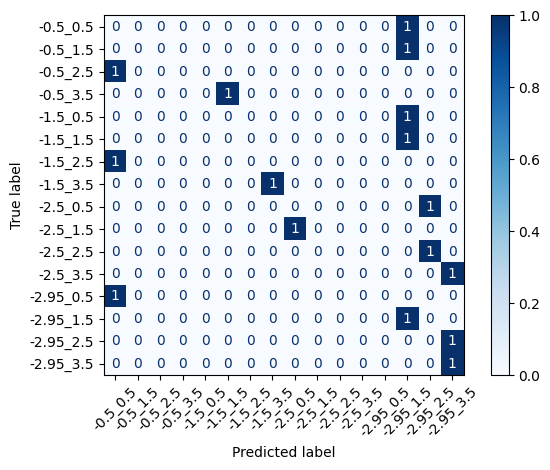

C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy : 0.1875
Precision: 0.0958
Recall   : 0.1875
accuracy:0.1875,precision:0.09583333333333333,recall:0.1875


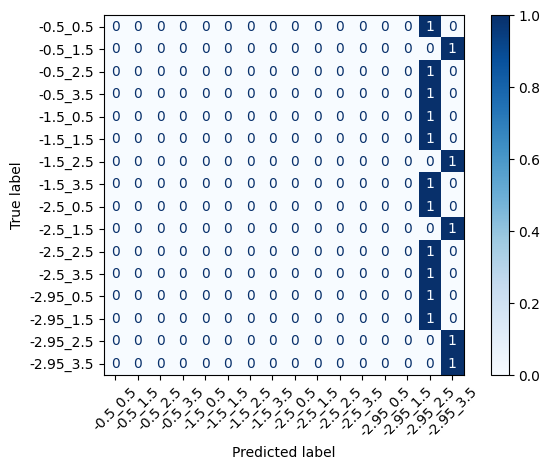

C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy : 0.0625
Precision: 0.0125
Recall   : 0.0625
accuracy:0.0625,precision:0.0125,recall:0.0625


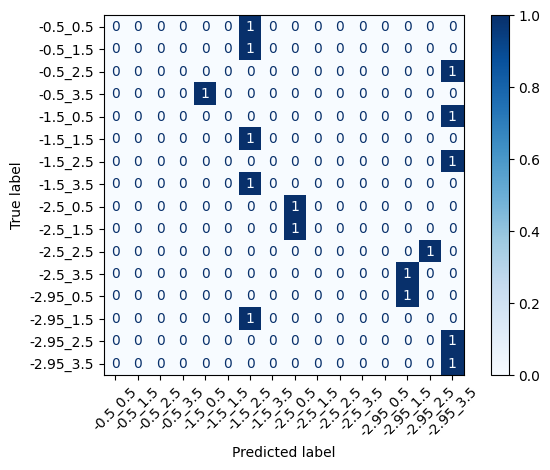

C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Accuracy : 0.1250
Precision: 0.0437
Recall   : 0.1250
accuracy:0.125,precision:0.04375,recall:0.125
sensors_numbers:3
best_results_for_all_sensors:{0: {'score': 0.17279411764705882, 'model': Pipeline(steps=[('columnslice', ColumnSliceTransformer()),
                ('scaler', StandardScaler()), ('PCA', PCA(n_components=4)),
                ('model', LogisticRegression(C=1, max_iter=5000))]), 'parameters': {'PCA__n_components': 4, 'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}, 'name': 'LogisticRegression'}, 1: {'score': 0.12279411764705883, 'model': Pipeline(steps=[('columnslice', ColumnSliceTransformer(slice_idx=1)),
                ('scaler', StandardScaler()), ('PCA', PCA(n_components=2)),
                ('model', SVC(C=1))]), 'parameters': {'PCA__n_components': 2, 'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}, 'name': 'SVC'}, 2: {'score': 0.1345588235294118, 'model': Pipeline(steps=[('columnslice', ColumnSliceTransformer(slice_idx=2)),
         

KeyError: 2

In [65]:
column_to_take = "VOC original"
room_case = "Only closed"
extra_params = { "keepOpenDoorData" :False}

parametersResultsGathered = loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered)

In [ ]:
parametersResultsGathered.loc[room_case]

#### VOC

In [ ]:
column_to_take = "VOC"
room_case = "Only closed"
extra_params = { "keepOpenDoorData" :False}

parametersResultsGathered = loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered)

In [ ]:
parametersResultsGathered.loc[room_case]

#### VOC rolling average

In [ ]:
column_to_take = "VOC rolling average"
room_case = "Only closed"
extra_params = { "keepOpenDoorData" :False}

parametersResultsGathered = loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered)

In [ ]:
parametersResultsGathered.loc[room_case]

In [ ]:
df_sorted = parametersResultsGathered.sort_values(
    by="EUCLIDIAN",
    key=lambda col: col.abs()
)
df_sorted

### ALL DATA

#### VOC Original

In [ ]:
column_to_take = "VOC original"
room_case = "All data"
extra_params = { "keepOpenDoorData" :True}

parametersResultsGathered = loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered)

In [ ]:
parametersResultsGathered.head(60)

#### VOC

In [ ]:
column_to_take = "VOC"
room_case = "All data"
extra_params = { "keepOpenDoorData" :True}

parametersResultsGathered = loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered)

In [ ]:
parametersResultsGathered.head(60)

#### VOC rolling average

In [ ]:
column_to_take = "VOC rolling average"
room_case = "All data"
extra_params = { "keepOpenDoorData" :True}

parametersResultsGathered = loopTroughFunctions(userInputData_Original,timeSeriesData_BIG_Original,models,column_to_take,room_case,extra_params,parametersResultsGathered)

In [ ]:
parametersResultsGathered.head(60)

In [ ]:
df_sorted = parametersResultsGathered.sort_values(
    by="EUCLIDIAN",
    key=lambda col: col.abs()
)
df_sorted

### END